In [2]:
%matplotlib inline
import sys
sys.path.insert(0, '/home/space/kai/src/Viscid/')
#sys.path.insert(0, '/home/space/dominic/Viscid')

import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import viscid
from viscid.plot import vpyplot as vlt
import h5py
import pandas as pd
import os
from mpl_toolkits import mplot3d

viscid.calculator.evaluator.enabled = True

%config InlineBackend.figure_format = 'retina'


project_dir="/mnt/lustre/lus0/project/mms"


from scipy.signal import savgol_filter



#%matplotlib notebook







In [3]:
project_dir="/mnt/lustre/lus0/project/mms"
#project_dir="/mnt/lustre/lus0/home/space/kai/project-mms"
run = project_dir+"/mms_kg200/pfd.xdmf"
dir = project_dir+"/mms_kg200"
fp = viscid.load_file(run, force_reload=True)

fp.activate_time(17)


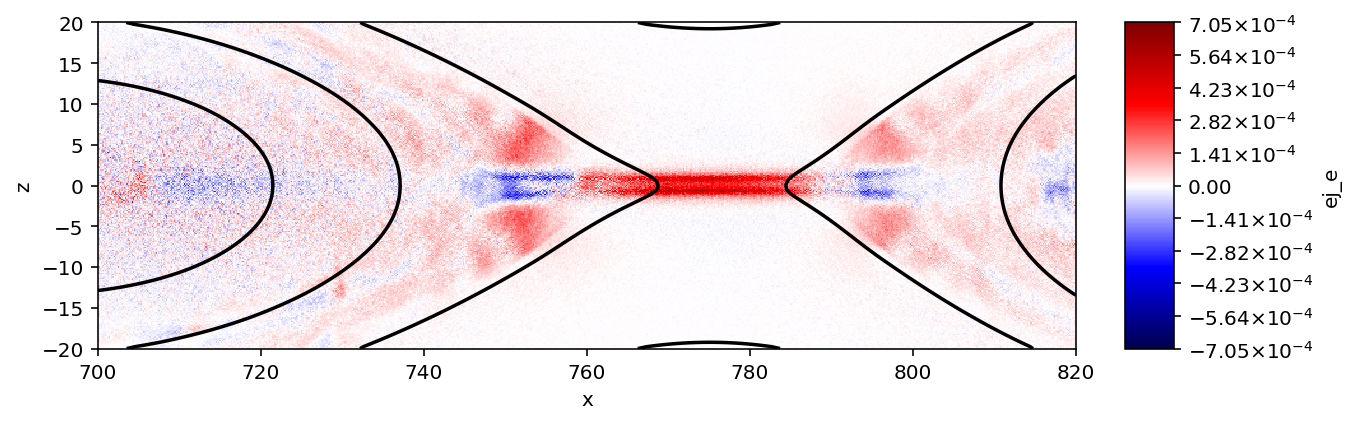

In [4]:
def make_plot(time, run, fldnames=["jy"], **kwargs):
    fig, ax = plt.subplots(len(fldnames), 1, figsize=(50,3*len(fldnames)))
    if not isinstance(ax, np.ndarray): ax = [ax]
    for i, fldname in enumerate(fldnames):
        # Hack around some inconsistencies with the field naming
        if run.endswith(".vpc"):
            map = {
                "bx_fc": "Magnetic Field X",
                "by_fc": "Magnetic Field Y",
                "bz_fc": "Magnetic Field Z",
                "jx": "Free Current Field X",
                "jy": "Free Current Field Y",
                
                "jz": "Free Current Field Z",
                "rho_nc": "Charge Density",
                "qn_nc_e": "Charge Density (ehydro)",
                "qn_nc_i": "Charge Density (Hhydro)",
                "jy_nc_e": "Current Density (ehydro) Y",
            }
        else:
            map = {
                "bx_fc": "hx_fc",
                "by_fc": "hy_fc",
                "bz_fc": "hz_fc",
                "qn_nc_e": "rho_nc_e",
                "qn_nc_i": "rho_nc_i",
            }
        vf = viscid.load_file(run, force_reload=True)
        vf.activate_time(time)
        _fldname = map[fldname] if fldname in map else fldname
        mid_val = 0
        
        vlt.plot(vf[_fldname], ax=ax[i], **kwargs);
        #plt.scatter(knots[0], knots[2], color = 'k')
        vlt.plot(vf["psi"],style="contour",levels=50,colors='k', ax=ax[i], **kwargs);

        
selection = "x=700f:820f, z=-20f:20f"
# Not sure why contours aren't working here
make_plot(17, run, ["ej_e=(jx_nc_e*ex_ec + jy_nc_e*ey_ec + jz_nc_e*ez_ec)"],cmap = 'seismic',symmetric=True, selection = selection)

In [5]:
def VxB(v,B):
    x_comp = v[1]*B[2] - v[2]*B[1]
    y_comp = v[2]*B[0] - v[0]*B[2]
    z_comp = v[0]*B[1] - v[1]*B[0]
    
    vxb = np.array([x_comp, y_comp, z_comp])
    return vxb



    
# Original GetFields
# Quite slow
def GetFields(r):
    Ex, Ey, Ez = fp['ex_ec'], fp['ey_ec'], fp['ez_ec']
    Bx, By, Bz = fp['hx_fc'], fp['hy_fc'], fp['hz_fc']
    
    seed = viscid.seed.Point(r)
    
    def func(fld):
        for lines in viscid.interp(fld, seed):
            a = lines
        return a

    
    
    Ex = func(Ex)
    Ey = func(Ey)
    Ez = func(Ez)
    Bx = func(Bx)
    By = func(By)
    Bz = func(Bz)
    
    E = np.array([Ex, Ey, Ez])
    B = np.array([Bx, By, Bz])
    
    return E, B



# These values change depending on the run used
pt = np.array([0, 5, 350])
xl = np.array([0,-10,-200])
xh = xl + np.array([1600,20,400])
gdims = np.array([10240,1,2560])
dx = (xh - xl) / gdims

# Interp function for new Get_fields fuction 
def interp(a, pt):
    n = ((pt - xl)/dx).astype(int)
    return a[n[0],n[1],n[2]]


# New and improved GetFields
# Get_Fields is much faster, can do thousands of steps on the order of 1 min
# Does Require interp function above
def Get_Fields(r):
    Ex, Ey, Ez = fp['ex_ec'], fp['ey_ec'], fp['ez_ec']
    Bx, By, Bz = fp['hx_fc'], fp['hy_fc'], fp['hz_fc']
    
    
    r = np.array([r[0],0,r[2]]) # This Resets the y position to zero
    Ex = interp(Ex,r)
    Ey = interp(Ey,r)
    Ez = interp(Ez,r)
    Bx = interp(Bx,r)
    By = interp(By,r)
    Bz = interp(Bz,r)
    
    E = np.array([Ex, Ey, Ez])
    B = np.array([Bx, By, Bz])
    
    return E, B






# NOTE:  The new Get_Fields does NOT return the exact same field values as old GetFields, although they are very close
# This results in slight differences in the trajecories, but they are still very similar to each other
#  over the course of hundreds of steps
# Which method is 'more correct' is hard to say. The produce similar results but one is much faster

In [6]:
sl = np.array([750,0,-2])
sh = np.array([752,0,-1])
il = ((sl - xl) / dx).astype(int)
ih = ((sh - xl) / dx).astype(int)

t = 17
dirlist = os.listdir(dir)
dirlist = [x for x in dirlist if "prt" in x ]


def read_particles(dir, step=0, proc=0):
    filename = "{}/prt.{:06d}_p{:06d}.h5".format(dir, step, proc)
    file = h5py.File(filename, "r")
    particles = file["particles/p0/1d"]
    idx_begin = file["particles/p0/idx_begin"]
    idx_end = file["particles/p0/idx_end"]

    return particles, idx_begin, idx_end

#This defines the variable ThePrt: a 5 or 6 digit number indicating
#the timestep in the particle output file
if dirlist[t][:5] == 'prt.1':
    ThePrt = int(dirlist[t][4:10]) 
else:
    ThePrt = int(dirlist[t][5:10])

#Read_Particles will force the 2nd argument to be 6 digits anyway, 
# so if ThePrt = 95069 read particles automatically matches the prt format
# with 095069
particles, idx_begin, idx_end = read_particles(dir, ThePrt)
#This defines the variable ThePrt: a 5 or 6 digit number indicating
#the timestep in the particle output file

#particles, idx_begin, idx_end = read_particles(dir, 36568)





def in_cell(kind, iz, iy, ix):
    loc = kind, iz - particle_start[2], iy - particle_start[1], ix - particle_start[0]
    return slice(idx_begin[loc], idx_end[loc])

cnt = 0
slices = []
for iz in range(il[2], ih[2]):
    for ix in range(il[0], ih[0]):
        for kind in range(2):
            r = in_cell(kind, iz, 0, ix)
            cnt += int(r.stop - r.start)
            slices.append(r)
        
s_min = min(s.start for s in slices)
s_max = max(s.stop for s in slices)
    
prt = particles[0]
prts = np.zeros(cnt, dtype=prt.dtype)
cnt = 0
for sl in slices:
    l = int(sl.stop - sl.start)
    prts[cnt:cnt+l] = particles[sl.start:sl.stop]
    cnt += l
    
    
df = pd.DataFrame(prts)




def Particle_Select():
    df['eng_sqrd'] = (df['px']**2 + df['py']**2 + df['pz']**2)
    
    min = df.loc[lambda df: df['eng_sqrd'] == df["eng_sqrd"].min()]
    med = df.loc[lambda df: df['eng_sqrd'] == df["eng_sqrd"].median()]
    max = df.loc[lambda df: df['eng_sqrd'] == df["eng_sqrd"].max()]
    
    minmed = df.loc[lambda df: df['eng_sqrd'] < df["eng_sqrd"].median()]
    minmed = minmed.loc[lambda df: minmed['eng_sqrd'] == minmed["eng_sqrd"].median()]
    
    medmax = df.loc[lambda df: df['eng_sqrd'] > df["eng_sqrd"].median()]
    medmax = medmax.loc[lambda df: medmax['eng_sqrd'] == medmax["eng_sqrd"].median()]
    
    r_min = np.array([min["x"].median(),min["y"].median(),min["z"].median()])
    p_min = np.array([min["px"].median(),min["py"].median(),min["pz"].median()])
    
    r_minmed = np.array([minmed["x"].median(),minmed["y"].median(),minmed["z"].median()])
    p_minmed = np.array([minmed["px"].median(),minmed["py"].median(),minmed["pz"].median()])
    
    r_med = np.array([med["x"].median(),med["y"].median(),med["z"].median()])
    p_med = np.array([med["px"].median(),med["py"].median(),med["pz"].median()])
    
    r_medmax = np.array([medmax["x"].median(),medmax["y"].median(),medmax["z"].median()])
    p_medmax = np.array([medmax["px"].median(),medmax["py"].median(),medmax["pz"].median()])
    
    r_max = np.array([max["x"].median(),max["y"].median(),max["z"].median()])
    p_max = np.array([max["px"].median(),max["py"].median(),max["pz"].median()])

    return r_min, r_minmed, r_med, r_medmax, r_max, p_min, p_minmed, p_med, p_medmax, p_max, 


r0,r1,r2,r3,r4,p0,p1,p2,p3,p4 = Particle_Select()



NameError: name 'particle_start' is not defined

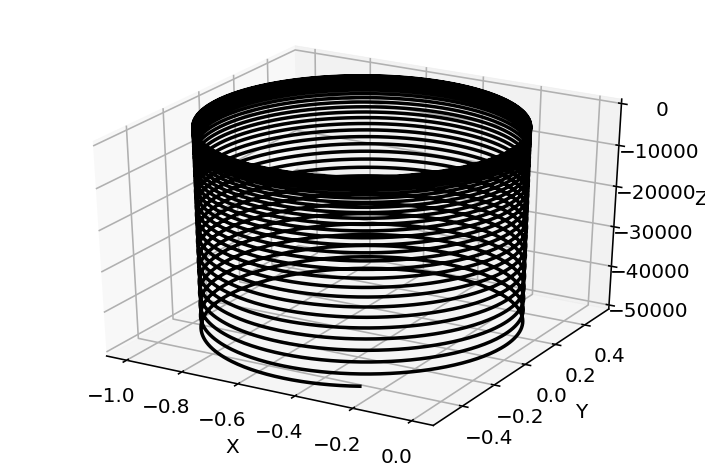

In [7]:
# Using Static E and B, plots a 3D trajectory


#m = 9.1e-31 # kg
#q = 1.6e-19 # C


#Just use these units for now
m = 1
q = -1

dt = 0.01 #s


E = np.array([0,0,10]) # V/m
B = np.array([0,0,2])
r0 = np.array([0,0,0]) # m
p0 = np.array([0,1,0]) # kg m/s

def Push(r0,p0,n):
    #Define position (r) & momentum (p) 
    r = np.zeros((n+1,3))
    p = np.zeros((n+1,3))
    
    #Initial r & p
    r[0] = r0
    p[0] = p0
    
    for i in range(n):
        
        
        # Convenient rotation vector 
        b_rot = q*B*dt/2*m
        
        # 1st half of electric push
        p_1 = p[i] + q*E*dt/2
        
        # Rotation by VxB
        p_2 = p_1 + 2*VxB((p_1 + VxB(p_1,b_rot))/(1+np.linalg.norm(b_rot)**2),b_rot)
        
        # 2nd half of electric push 
        p[i+1] = p_2 + q*E*dt/2
        r[i+1] = r[i] + p[i+1]*dt/m
    
    
    
    
    return r,p



r,p = Push(r0,p0,10000)

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot3D(r[:,0],r[:,1],r[:,2], 'black')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')


plt.show()

#plt.plot(r[:,0],r[:,1])
#plt.ylabel('y position')
#plt.xlabel('x position')
#plt.show()





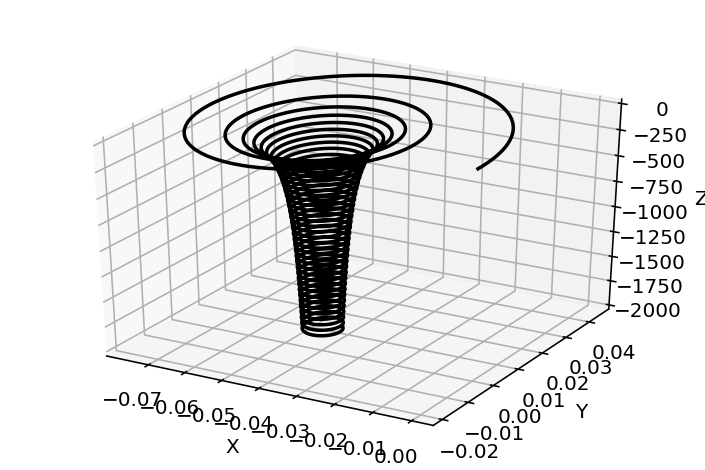

In [7]:
# Changing  B, static E parallel to B
#%matplotlib notebook
m = 1
q = -1

dt = 0.001 #s


E = np.array([0,0,1000]) # V/m
B = np.array([0,0,20])
r0 = np.array([0,0,0]) # m
p0 = np.array([0,1,0]) # kg m/s

B = np.zeros((2001,3))
B[0] = np.array([0,0,20])   

for i in range(2000):
    B[i+1,2] = B[i,2] +0.1  




def Push(r0,p0,n):
    #Define position (r) & momentum (p) 
    r = np.zeros((n+1,3))
    p = np.zeros((n+1,3))
    
    #Initial r & p
    r[0] = r0
    p[0] = p0
    
    for i in range(n):
        
        #E, B = GetFields(r[i])
        
        # Convenient rotation vector 
        b_rot = q*B[i]*dt/2*m
        
        # 1st half of electric push
        p_1 = p[i] + q*E*dt/2
        
        # Rotation by VxB
        p_2 = p_1 + 2*VxB((p_1 + VxB(p_1,b_rot))/(1+np.linalg.norm(b_rot)**2),b_rot)
        
        # 2nd half of electric push 
        p[i+1] = p_2 + q*E*dt/2
        r[i+1] = r[i] + p[i+1]*dt/m
    
    
    
    
    return r,p



r,p = Push(r0,p0,2000)

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot3D(r[:,0],r[:,1],r[:,2], 'black')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

In [ ]:
#make_plot(17, run, ['jx_ec'],cmap = 'seismic',symmetric=True, selection = selection)

i 0
2
i 1
2
i 2
2
i 3
2
i 4
2
i 5
2
i 6
2
i 7
2
i 8
2
i 9
2
i 10
2
i 11
2
i 12
2
i 13
2
i 14
2
i 15
2
i 16
2
i 17
2
i 18
2
i 19
2


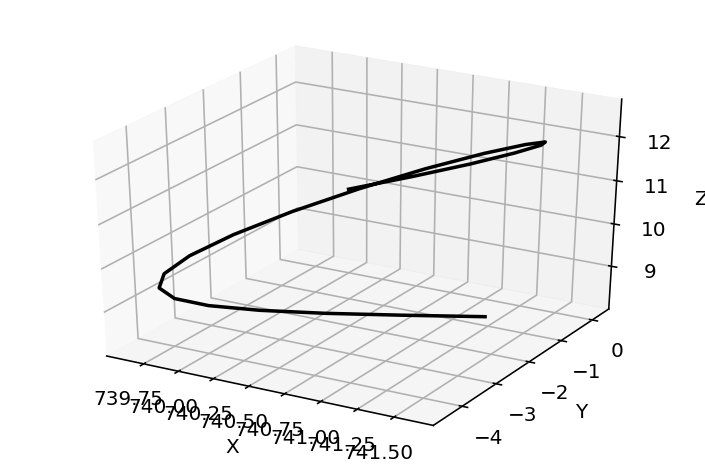

In [31]:
# Changing E and B with position

## This takes a while but seems to work 
## Should adjust dt and n around a bit 


m = 1
q = -1

dt = 1



r0 = np.array([740,0,10]) 
p0 = np.array([0.386,0.375,0.345]) 

def Push(r0,p0,n):
    #Define position (r) & momentum (p) 
    r = np.zeros((n+1,3))
    p = np.zeros((n+1,3))
    
    #Initial r & p
    r[0] = r0
    p[0] = p0
    
    #get_fields = GetFields(fp)
    for i in range(n):
        print('i', i)
        #E, B = get_fields.interp(r[i])
        E,B = Get_Fields(r[i])
        
        print('2')
        # Convenient rotation vector 
        b_rot = q*B*dt/2*m
        
        # 1st half of electric push
        p_1 = p[i] + q*E*dt/2
        
        # Rotation by VxB
        p_2 = p_1 + 2*VxB((p_1 + VxB(p_1,b_rot))/(1+np.linalg.norm(b_rot)**2),b_rot)
        
        # 2nd half of electric push 
        p[i+1] = p_2 + q*E*dt/2
        r[i+1] = r[i] + p[i+1]*dt/m
    
    
    
    return r,p



r,p = Push(r0,p0,20)

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot3D(r[:,0],r[:,1],r[:,2], 'black')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

In [54]:
a = np.array([1,2,3])
a[2] = 65
a

array([ 1,  2, 65])

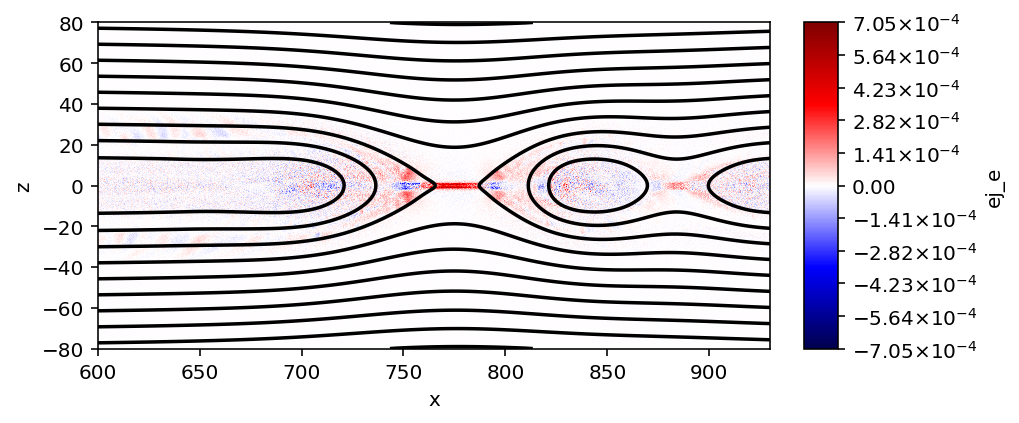

In [20]:
selection = "x=600f:930f, z=-80f:80f"

make_plot(17, run, ["ej_e=(jx_nc_e*ex_ec + jy_nc_e*ey_ec + jz_nc_e*ez_ec)"],cmap = 'seismic',symmetric=True, selection = selection)

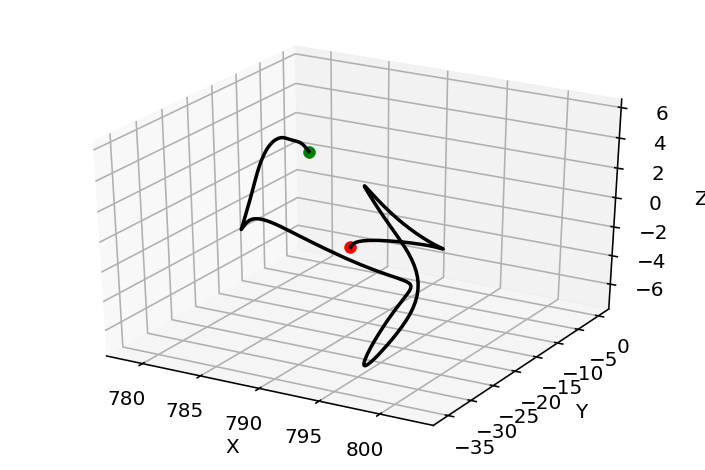

In [8]:
#%%timeit
#%matplotlib notebook
# Changing E and B with position

## This takes a while but seems to work 
## Should adjust dt and n around a bit 


m = 1
q = -1

dt = 1

xs = 2
zs = 30

#r0 = np.array([775+xs,0,0+zs]) 
#p0 = np.array([0,0,0]) 

r0 = np.array([777+xs,0,0]) 
p0 = np.array([0,0,0]) 

r1 = np.array([779+xs,0,0])
p1 = np.array([0,0,0])

r2 = np.array([781+xs,0,0]) 
p2 = np.array([0,0,0]) 


r3 = np.array([783+xs,0,0])
p3 = np.array([0,0,0])

r4 = np.array([785+xs,0,0])
p4 = np.array([0,0,0])

#r5 = np.array([783,0,0]) 
#r6 = np.array([790,0,0]) 


#p0 = np.array([0,0,0]) 


def Push(r0,p0,n):
    #Define position (r) & momentum (p) 
    r = np.zeros((n+1,3))
    p = np.zeros((n+1,3))
    
    #Initial r & p
    r[0] = r0
    p[0] = p0
    
    for i in range(n):

            E, B = Get_Fields(r[i])

            # Convenient rotation vector 
            b_rot = q*B*dt/2*m

            # 1st half of electric push
            p_1 = p[i] + q*E*dt/2

            # Rotation by VxB
            p_2 = p_1 + 2*VxB((p_1 + VxB(p_1,b_rot))/(1+np.linalg.norm(b_rot)**2),b_rot)

            # 2nd half of electric push 
            p[i+1] = p_2 + q*E*dt/2
            r[i+1] = r[i] + p[i+1]*dt/m
    
    
    
    
    return r,p


n = 210
r,p = Push(r0,p0,n)
r1,p1 = Push(r1,p1,n)
r2,p2 = Push(r2,p0,n)
r3,p3 = Push(r3,p0,n)
r4,p4 = Push(r4,p4,n)
#r5,p5 = Push(r5,p0,n)
#r4,p4 = Push(r3,p0,n)
#r5,p5 = Push(r3,p0,n)
#r6,p6 = Push(r3,p0,n)



fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot3D(r[:,0],r[:,1],r[:,2], 'black')
ax.scatter(r[0,0],r[0,1],r[0,2], marker = 'o', color = 'green',s = 35)
ax.scatter(r[-1,0],r[-1,1],r[-1,2], marker = 'o', color = 'red', s = 35)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

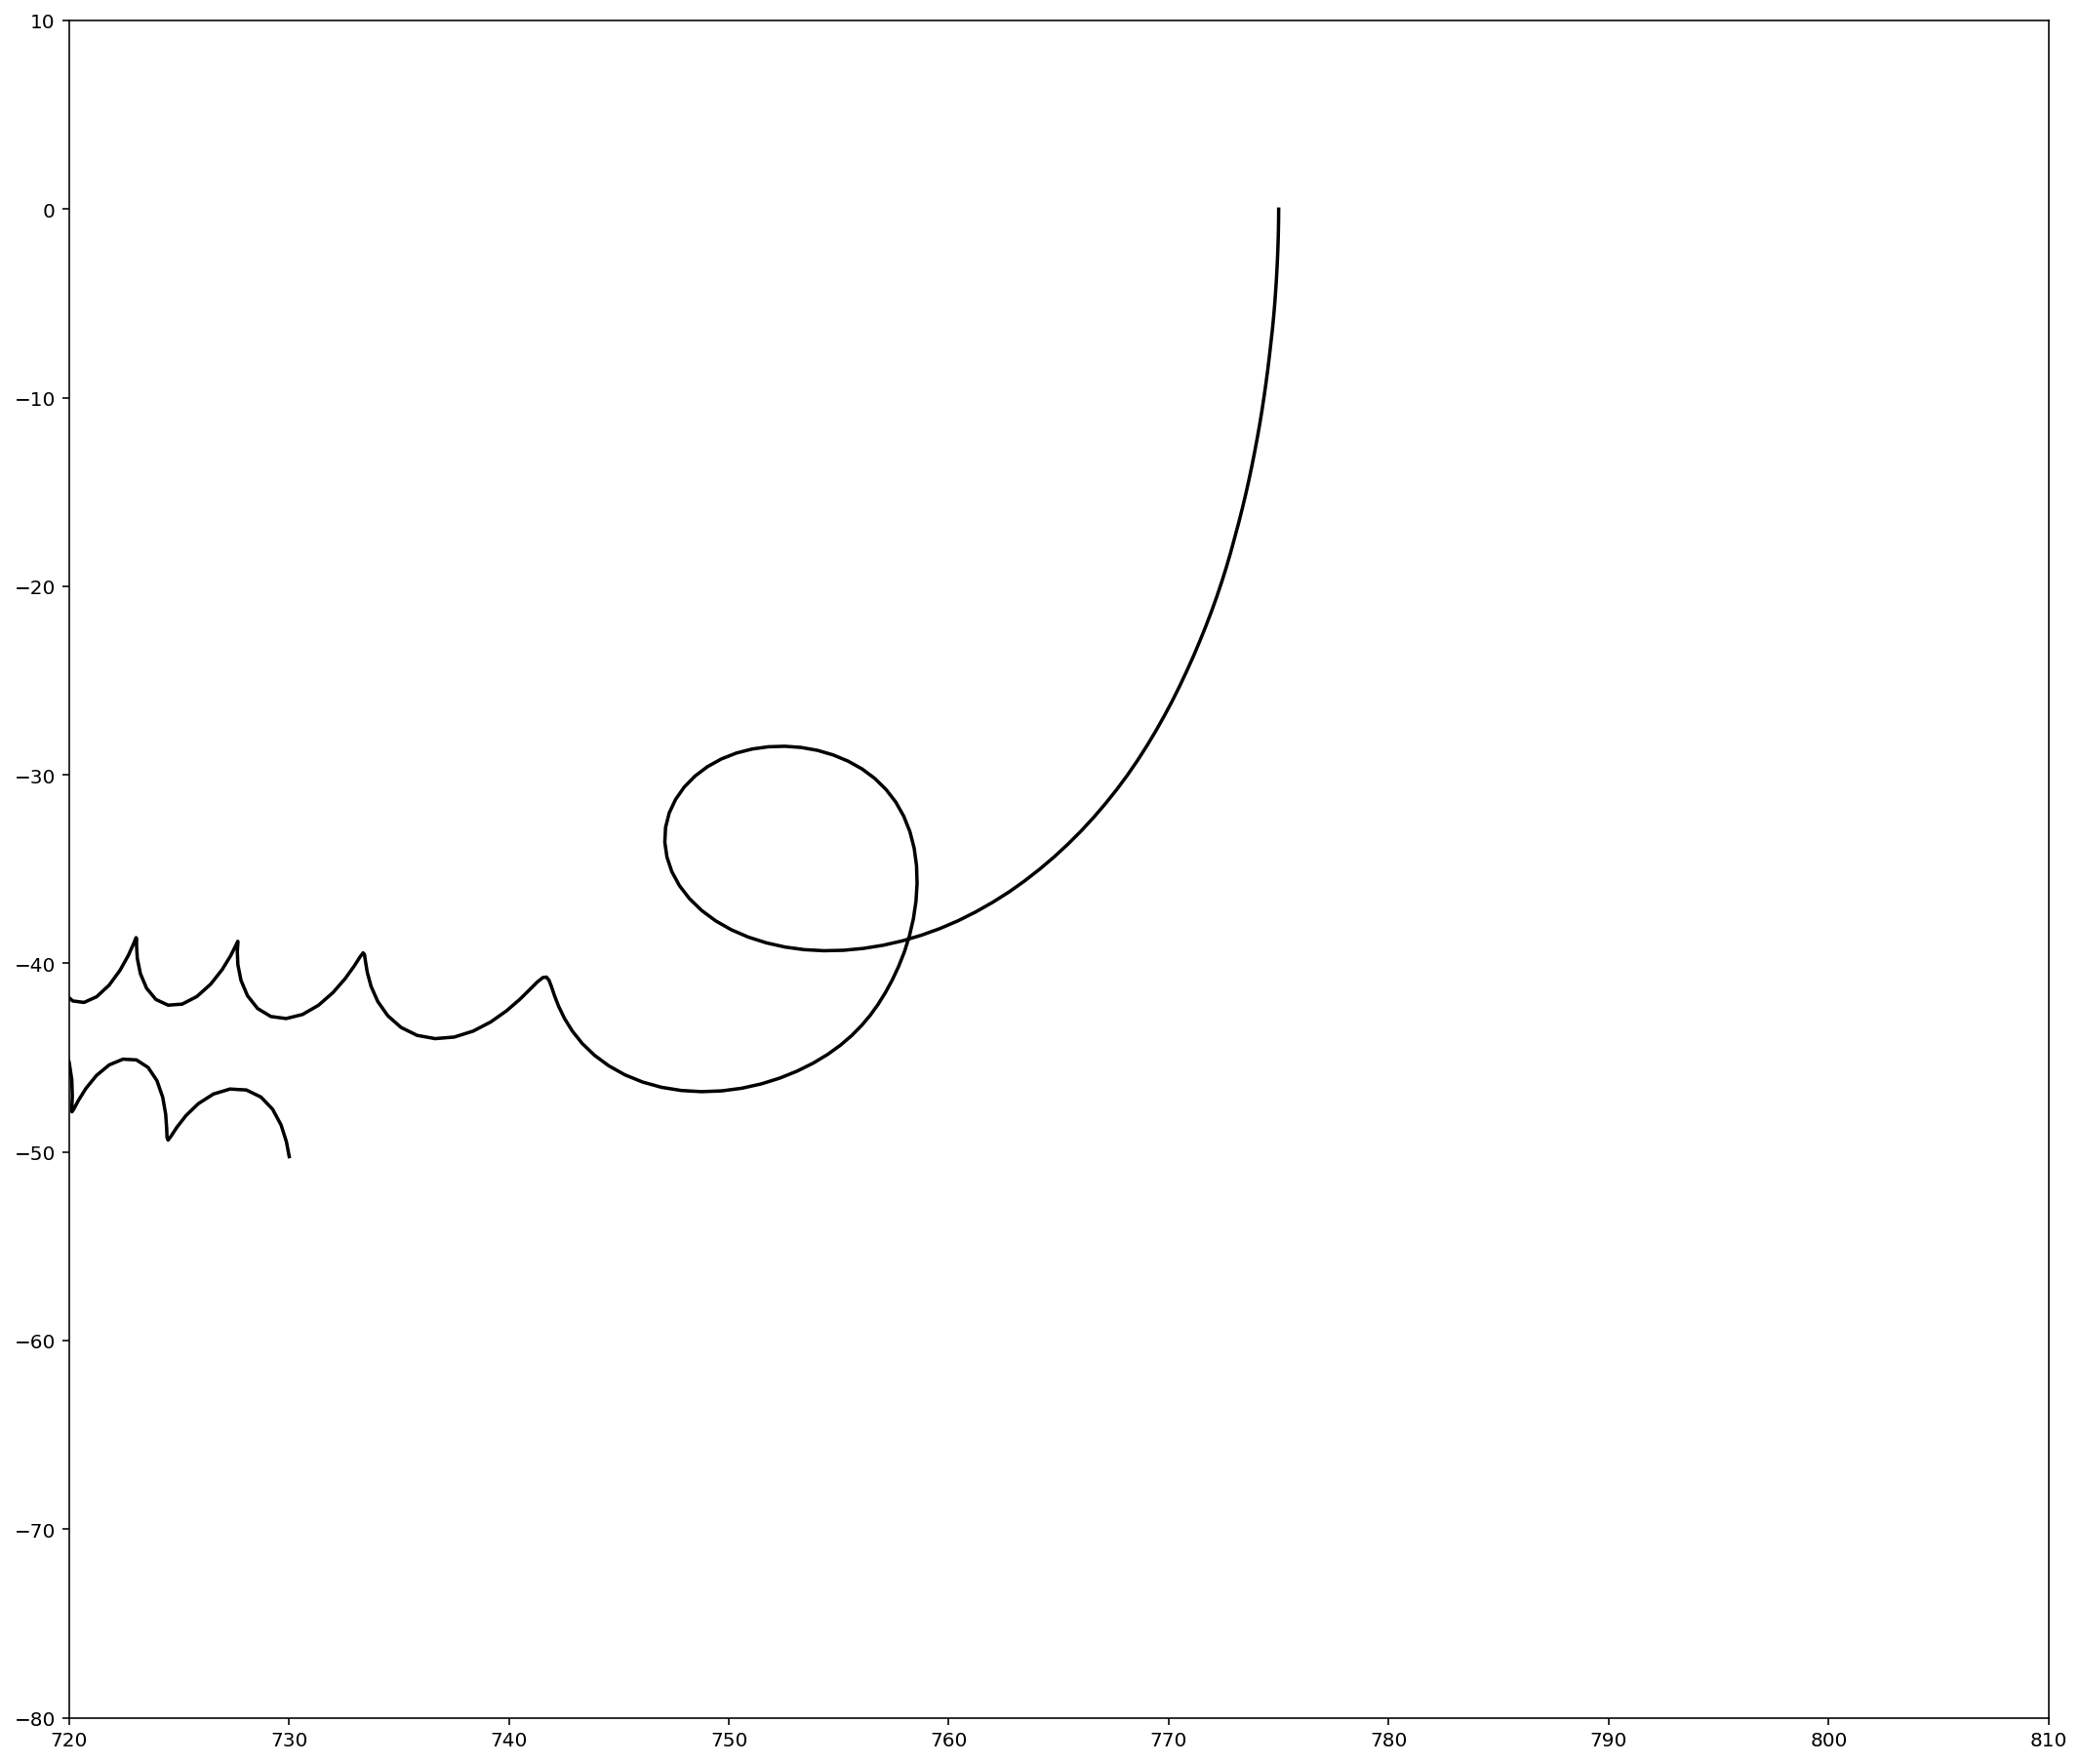

In [52]:
fld = "ej_e=(jx_nc_e*ex_ec + jy_nc_e*ey_ec + jz_nc_e*ez_ec)"

fp.activate_time(17)

plt.figure(figsize=(40,16))
plt.subplot(1,2,1)
plt.xlim(720,810)
plt.ylim(-80,10)

plt.plot(r[:,0],r[:,1], 'black')

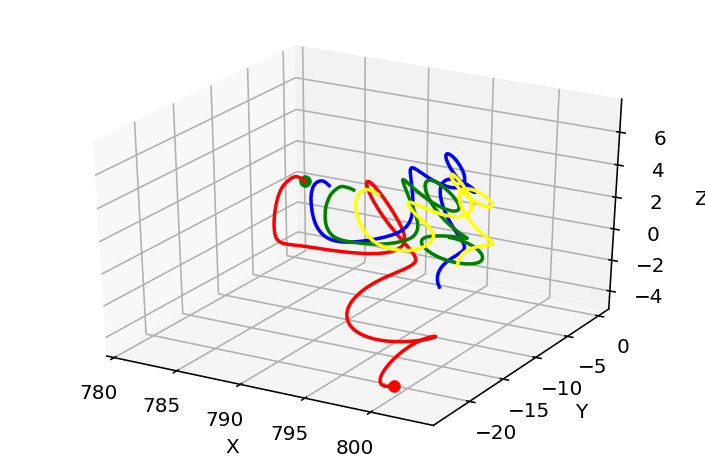

In [11]:
fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot3D(r1[:,0],r1[:,1],r1[:,2], 'red')
ax.plot3D(r2[:,0],r2[:,1],r2[:,2], 'blue')
ax.plot3D(r3[:,0],r3[:,1],r3[:,2], 'green')
ax.plot3D(r4[:,0],r4[:,1],r4[:,2], 'yellow')
#ax.plot3D(r5[:,0],r5[:,1],r5[:,2], 'orange')


ax.scatter(r1[0,0],r1[0,1],r1[0,2], marker = 'o', color = 'green',s = 35)
ax.scatter(r1[-1,0],r1[-1,1],r1[-1,2], marker = 'o', color = 'red', s = 35)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

NameError: name 'p1' is not defined

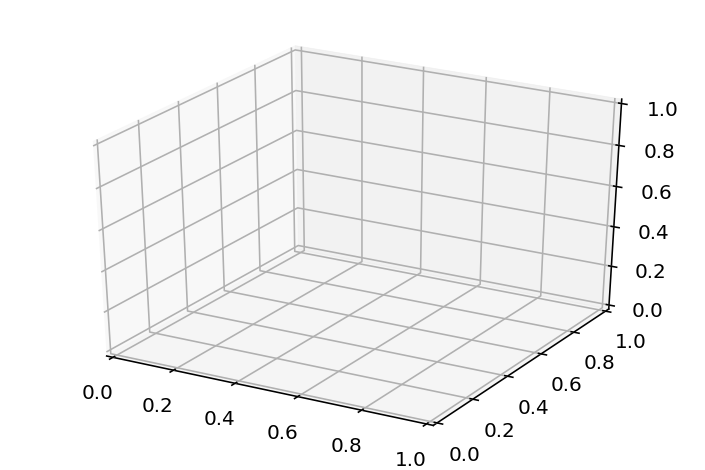

In [8]:
fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot3D(p1[:,0],p1[:,1],p1[:,2], 'black')
ax.scatter(p1[0,0],p1[0,1],p1[0,2], marker = 'o', color = 'green',s = 35)
ax.scatter(p1[-1,0],p1[-1,1],p1[-1,2], marker = 'o', color = 'red', s = 35)
ax.set_xlabel('PX')
ax.set_ylabel('PY')
ax.set_zlabel('PZ')

In [9]:
JEe = "ej_e=(jx_nc_e*ex_ec + jy_nc_e*ey_ec + jz_nc_e*ez_ec)"
JEi = "ej_i=(jx_nc_i*ex_ec + jy_nc_i*ey_ec + jz_nc_i*ez_ec)"

#These have an additional factor for viewing purposes
JE = "ej=((jx_nc_e+jx_nc_i)*ex_ec + (jy_nc_e+jy_nc_i)*ey_ec + (jz_nc_e+jz_nc_i)*ez_ec)"

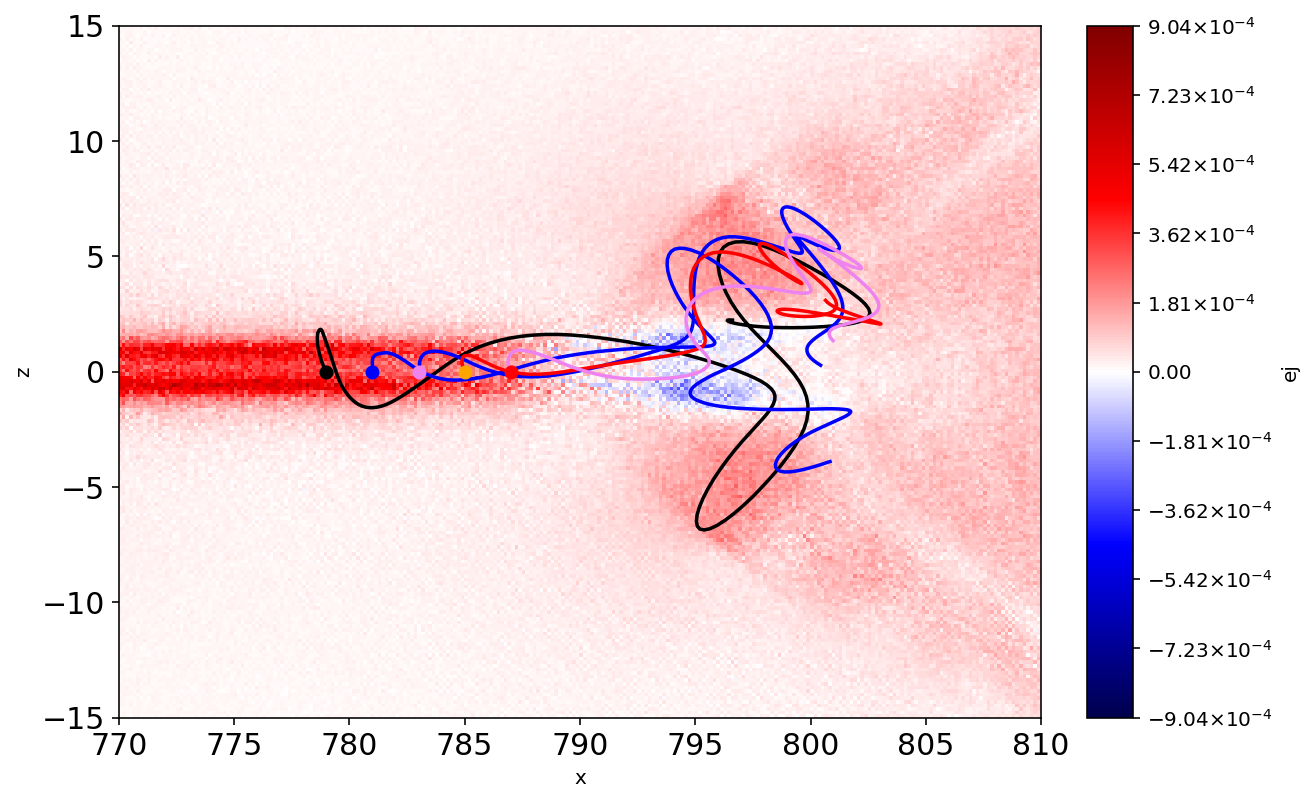

In [11]:
fld = JE

fp.activate_time(17)

plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
vlt.plot(fp[fld], cmap = "seismic", symmetric = "True")
#vlt.plot(fp["psi"],style="contour",levels=50,colors='k', ax=ax[i], **kwargs);
plt.axis("image")
plt.xlim(770,810)
plt.ylim(-15,15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

plt.plot(r[:,0],r[:,2], 'black')
plt.plot(r[0,0],r[0,2], marker = 'o', color = 'black')

plt.plot(r1[:,0],r1[:,2], 'blue')
plt.plot(r1[0,0],r1[0,2], marker = 'o', color = 'blue')

plt.plot(r2[:,0],r2[:,2], 'blue')
plt.plot(r2[0,0],r2[0,2], marker = 'o', color = 'violet')

plt.plot(r3[:,0],r3[:,2], 'red')
plt.plot(r3[0,0],r3[0,2], marker = 'o', color = 'orange')

plt.plot(r4[:,0],r4[:,2], 'violet')
plt.plot(r4[0,0],r4[0,2], marker = 'o', color = 'red')



#plt.plot(r6[:,0],r6[:,2], 'red')




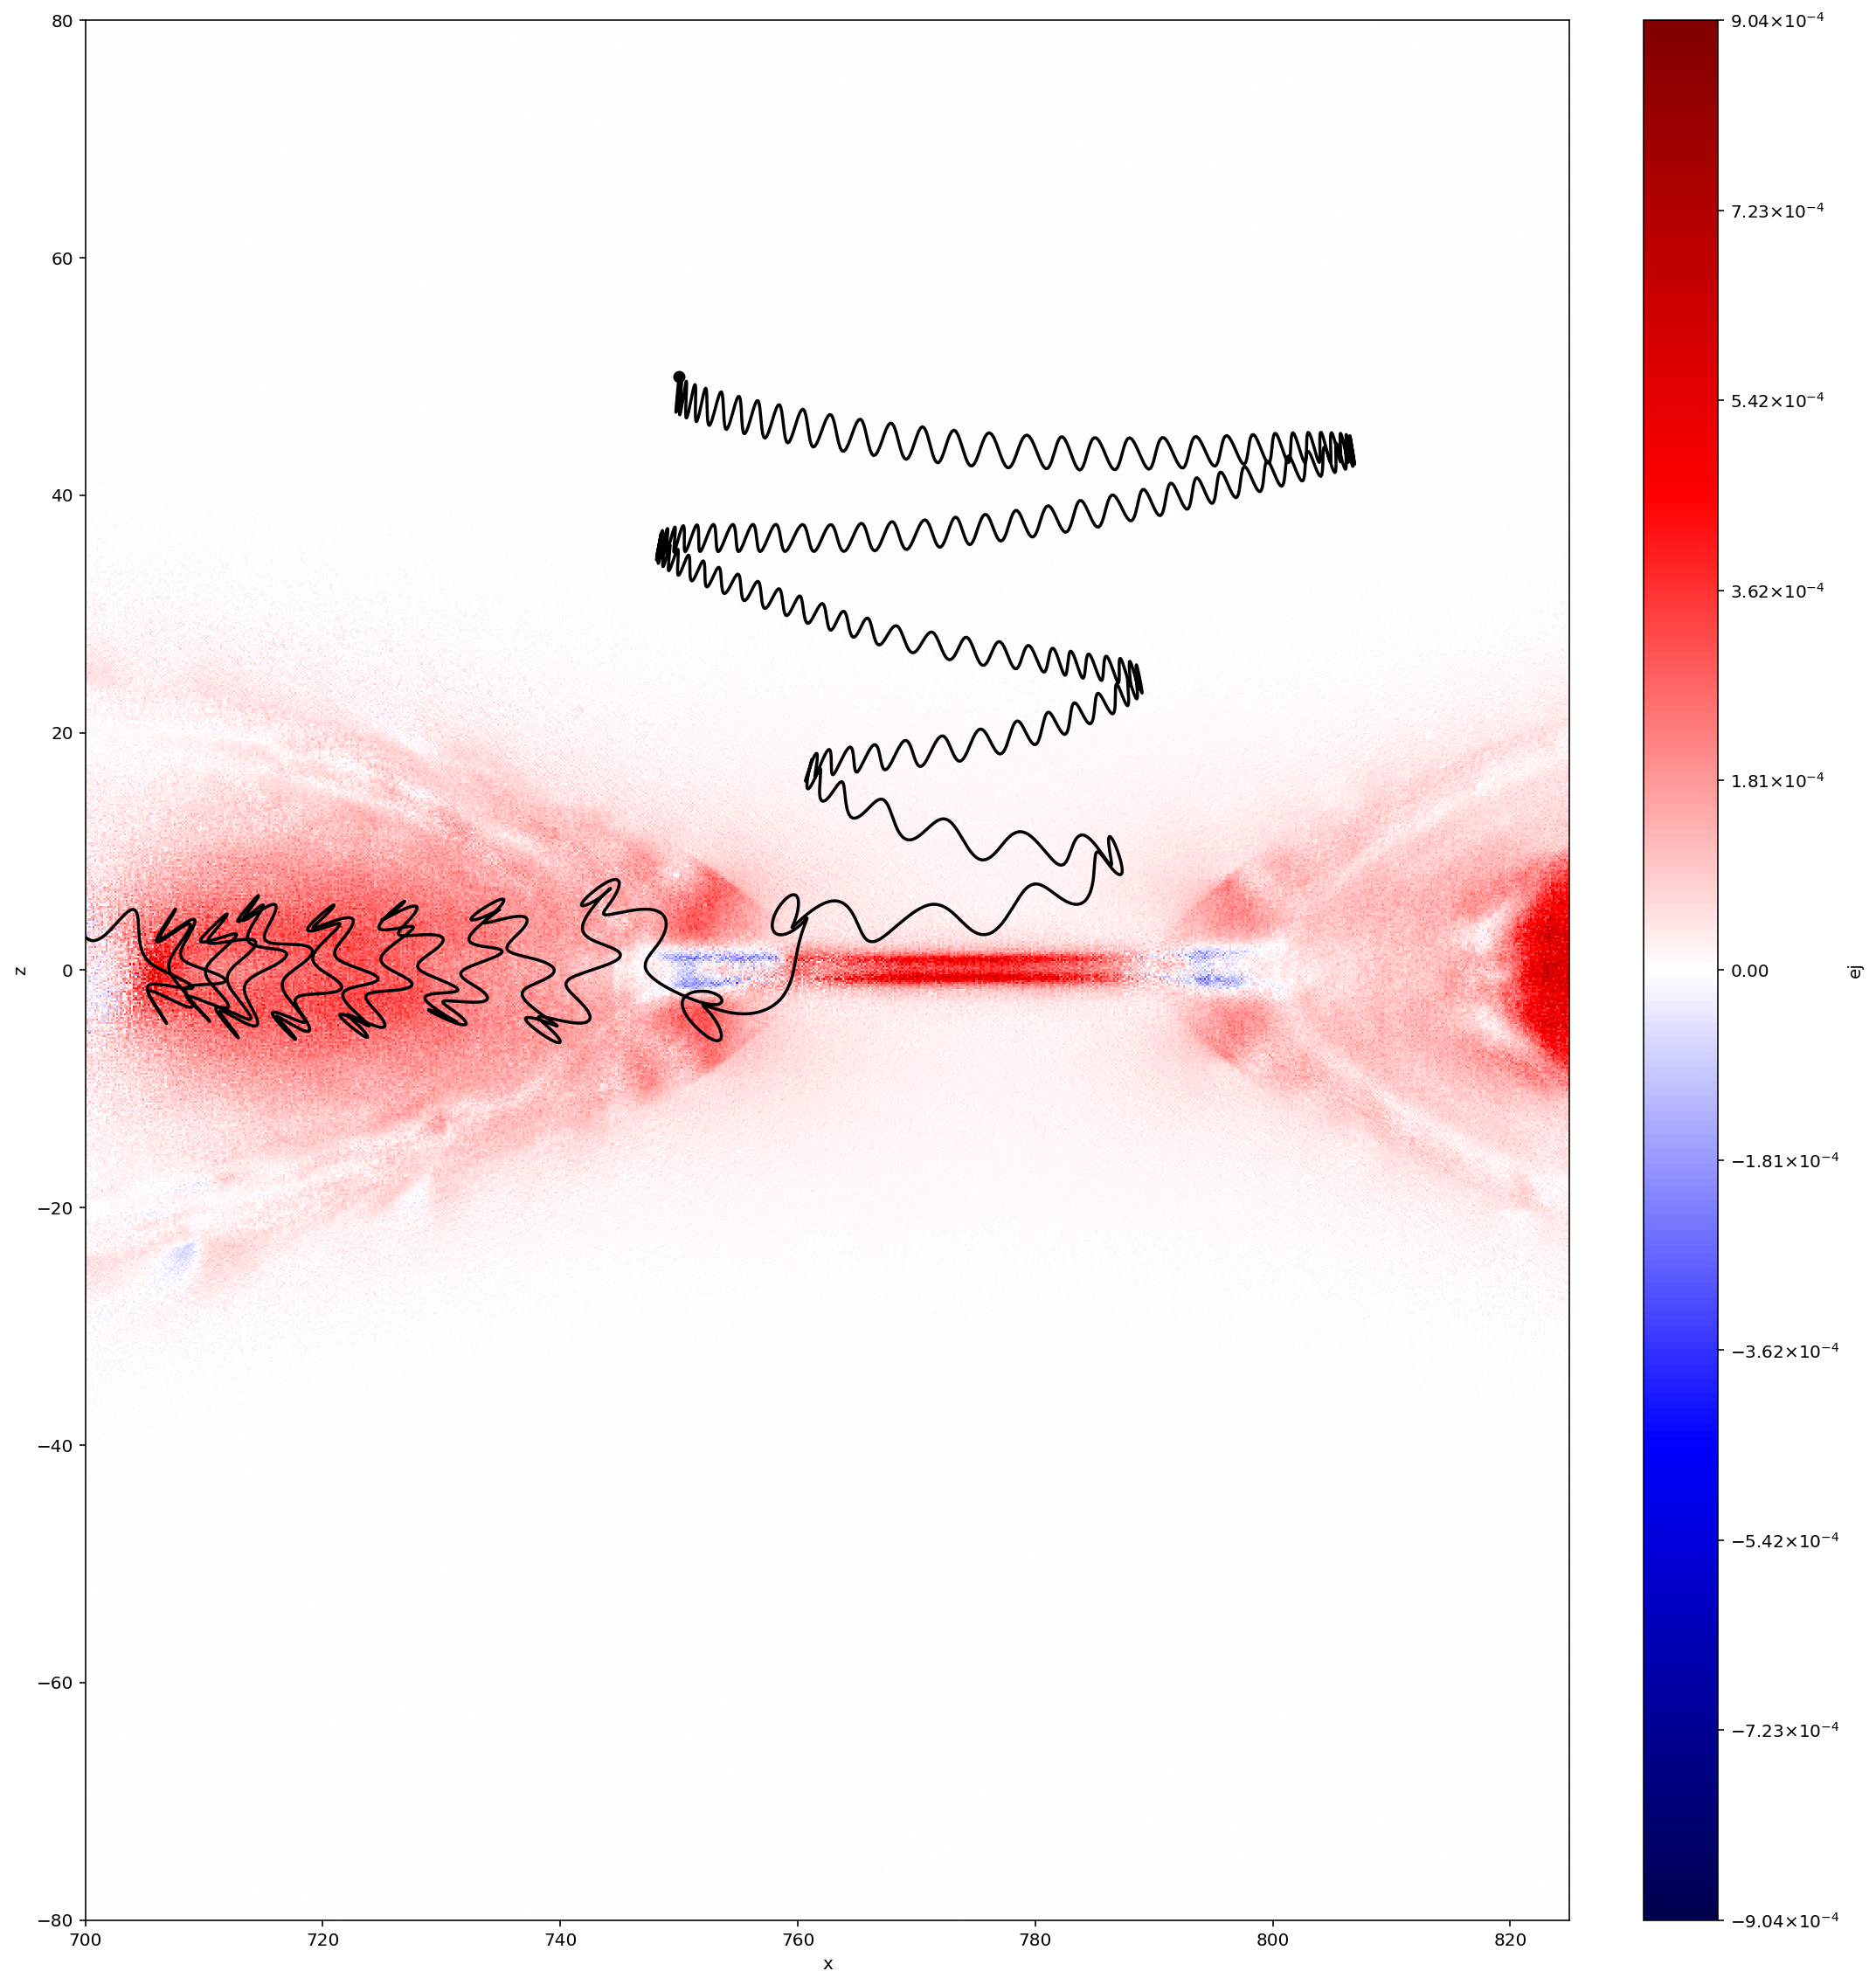

In [14]:
fld = JE

fp.activate_time(17)

plt.figure(figsize=(40,20))
plt.
plt.subplot(1,2,1)
vlt.plot(fp[fld], cmap = "seismic", symmetric = "True")
#vlt.plot(fp["psi"],style="contour",levels=50,colors='k', ax=ax[i], **kwargs);
plt.axis("image")
plt.xlim(700,825)
plt.ylim(-80,80)

plt.plot(r[:,0],r[:,2], 'black')
plt.plot(r[0,0],r[0,2], marker = 'o', color = 'black')


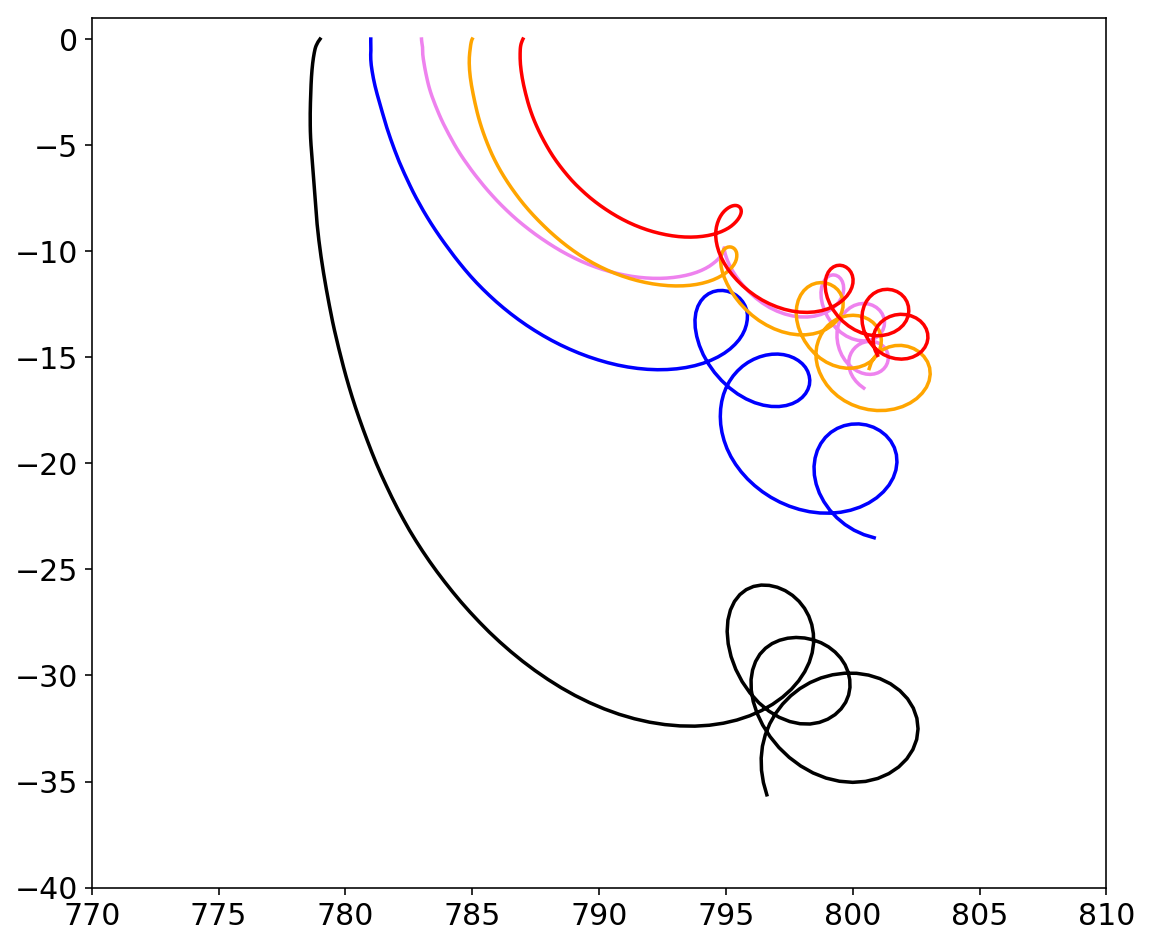

In [12]:
fld = "ej_e=(jx_nc_e*ex_ec + jy_nc_e*ey_ec + jz_nc_e*ez_ec)"

fp.activate_time(17)

plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
plt.xlim(770,810)
plt.ylim(-40,1)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

plt.plot(r[:,0],r[:,1], 'black')
plt.plot(r1[:,0],r1[:,1], 'blue')
plt.plot(r2[:,0],r2[:,1], 'violet')
plt.plot(r3[:,0],r3[:,1], 'orange')
plt.plot(r4[:,0],r4[:,1], 'red')
#plt.plot(r5[:,0],r5[:,1], 'yellow')
#plt.plot(r6[:,0],r6[:,2], 'red')


